In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("../data/raw/topics.csv")

df

,topic,exam_importance,difficulty,student_knowledge,estimated_minutes
0,HTTP,9,6,3,60
1,TCP Congestion Control,10,8,2,75
2,UDP,5,3,8,25
3,DNS,6,4,5,35
4,Routing,8,7,3,60
5,Application Layer Protocols,7,5,4,45
6,Client Server Architecture,4,3,8,20
7,P2P Architecture,4,4,6,30


In [3]:
df.shape

(8, 5)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   topic              8 non-null      str  
 1   exam_importance    8 non-null      int64
 2   difficulty         8 non-null      int64
 3   student_knowledge  8 non-null      int64
 4   estimated_minutes  8 non-null      int64
dtypes: int64(4), str(1)
memory usage: 452.0 bytes


In [8]:
df.describe()

,exam_importance,difficulty,student_knowledge,estimated_minutes
count,8.000000,8.00000,8.000000,8.000000
mean,6.625000,5.00000,4.875000,43.750000
std,2.263846,1.85164,2.295181,19.594095
min,4.000000,3.00000,2.000000,20.000000
25%,4.750000,3.75000,3.000000,28.750000
50%,6.500000,4.50000,4.500000,40.000000
75%,8.250000,6.25000,6.500000,60.000000
max,10.000000,8.00000,8.000000,75.000000


In [6]:
df.isnull().sum()

topic                0
exam_importance      0
difficulty           0
student_knowledge    0
estimated_minutes    0
dtype: int64

In [9]:
df["knowledge_gap"] = 10 - df["student_knowledge"]

In [10]:
df

,topic,exam_importance,difficulty,student_knowledge,estimated_minutes,knowledge_gap
0,HTTP,9,6,3,60,7
1,TCP Congestion Control,10,8,2,75,8
2,UDP,5,3,8,25,2
3,DNS,6,4,5,35,5
4,Routing,8,7,3,60,7
5,Application Layer Protocols,7,5,4,45,6
6,Client Server Architecture,4,3,8,20,2
7,P2P Architecture,4,4,6,30,4


In [11]:
df["priority_score"] = (
    df["exam_importance"]
    * df["knowledge_gap"]
    * df["difficulty"]
)

In [12]:
df[
    [
        "topic",
        "exam_importance",
        "student_knowledge",
        "knowledge_gap",
        "difficulty",
        "priority_score"        
    ]
]

,topic,exam_importance,student_knowledge,knowledge_gap,difficulty,priority_score
0,HTTP,9,3,7,6,378
1,TCP Congestion Control,10,2,8,8,640
2,UDP,5,8,2,3,30
3,DNS,6,5,5,4,120
4,Routing,8,3,7,7,392
5,Application Layer Protocols,7,4,6,5,210
6,Client Server Architecture,4,8,2,3,24
7,P2P Architecture,4,6,4,4,64


In [13]:
priority_df = df.sort_values(
    by="priority_score",
    ascending=False
)

In [14]:
priority_df[
    [
        "topic",
        "priority_score",
        "estimated_minutes"
    ]
]

,topic,priority_score,estimated_minutes
1,TCP Congestion Control,640,75
4,Routing,392,60
0,HTTP,378,60
5,Application Layer Protocols,210,45
3,DNS,120,35
7,P2P Architecture,64,30
2,UDP,30,25
6,Client Server Architecture,24,20


In [15]:
df["priority_per_minute"] = (
    df["priority_score"] /
    df["estimated_minutes"]
)

In [16]:
priority_df = df.sort_values(
    by="priority_per_minute",
    ascending=False
)

In [17]:
priority_df[
    [
        "topic",
        "priority_score",
        "estimated_minutes",
        "priority_per_minute"
    ]
]

,topic,priority_score,estimated_minutes,priority_per_minute
1,TCP Congestion Control,640,75,8.533333
4,Routing,392,60,6.533333
0,HTTP,378,60,6.300000
5,Application Layer Protocols,210,45,4.666667
3,DNS,120,35,3.428571
7,P2P Architecture,64,30,2.133333
2,UDP,30,25,1.200000
6,Client Server Architecture,24,20,1.200000


In [18]:
available_minutes = 180

In [23]:
remaining_time = available_minutes
selected_topics = []

for _, row in priority_df.iterrows():

    if row["estimated_minutes"] <= remaining_time:
        selected_topics.append(row["topic"])
        remaining_time -= row["estimated_minutes"]

In [24]:
selected_topics

['TCP Congestion Control', 'Routing', 'Application Layer Protocols']

In [25]:
remaining_time

0

In [26]:
used_time = available_minutes - remaining_time

print("Available_time:", available_minutes, "minutes")
print("used_tiems", used_time, "minutes")
print("remaining_time", remaining_time, "minutes")

Available_time: 180 minutes
used_tiems 180 minutes
remaining_time 0 minutes


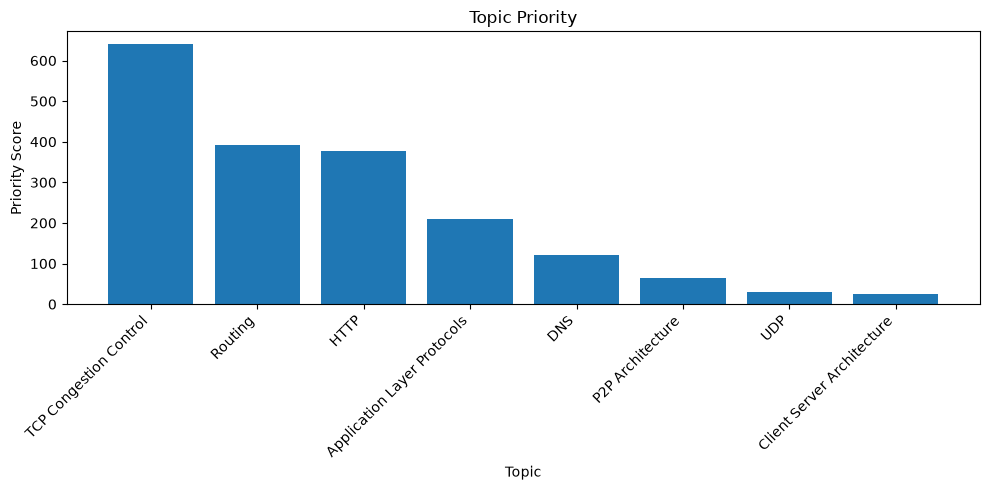

In [28]:
plt.figure(figsize=(10,5))

plt.bar(
    priority_df["topic"],
    priority_df["priority_score"]
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Topic")
plt.ylabel("Priority Score")
plt.title("Topic Priority")

plt.tight_layout()
plt.show()

In [29]:
df.loc[df["topic"] == "HTTP", "student_knowledge"] = 8
df.loc[df["topic"] == "TCP Congestion Control", "student_knowledge"] = 7
df.loc[df["topic"] == "Routing", "student_knowledge"] = 6

In [30]:
df["knowledge_gap"] = 10 - df["student_knowledge"]

In [31]:
df["priority_score"] = (
    df["exam_importance"]
    * df["knowledge_gap"]
    * df["difficulty"]
)

In [32]:
df["priority_per_minute"] = (
    df["priority_score"]
    / df["estimated_minutes"]
)

In [33]:
priority_df = df.sort_values(
    by="priority_per_minute",
    ascending=False
)

In [34]:
priority_df[
    [
        "topic",
        "student_knowledge",
        "knowledge_gap",
        "priority_score",
        "priority_per_minute"
    ]
]

,topic,student_knowledge,knowledge_gap,priority_score,priority_per_minute
5,Application Layer Protocols,4,6,210,4.666667
4,Routing,6,4,224,3.733333
3,DNS,5,5,120,3.428571
1,TCP Congestion Control,7,3,240,3.200000
7,P2P Architecture,6,4,64,2.133333
0,HTTP,8,2,108,1.800000
2,UDP,8,2,30,1.200000
6,Client Server Architecture,8,2,24,1.200000


In [35]:
df.to_csv("../data/raw/topics.csv", index=False)

In [36]:
available_minutes = 120

remaining_time = available_minutes
selected_topics = []

for _, row in priority_df.iterrows():
    if row["estimated_minutes"] <= remaining_time:
        selected_topics.append(row["topic"])
        remaining_time -= row["estimated_minutes"]

print("Selected topics:", selected_topics)
print("Available time:", available_minutes, "minutes")
print("Used time:", available_minutes - remaining_time, "minutes")
print("Remaining time:", remaining_time, "minutes")

Selected topics: ['Application Layer Protocols', 'Routing']
Available time: 120 minutes
Used time: 105 minutes
Remaining time: 15 minutes


In [37]:
available_minutes = 300

In [38]:
remaining_time = available_minutes
selected_topics = []

for _, row in priority_df.iterrows():
    if row["estimated_minutes"] <= remaining_time:
        selected_topics.append(row["topic"])
        remaining_time -= row["estimated_minutes"]

print("Selected topics:", selected_topics)
print("Available time:", available_minutes, "minutes")
print("Used time:", available_minutes - remaining_time, "minutes")
print("Remaining time:", remaining_time, "minutes")

Selected topics: ['Application Layer Protocols', 'Routing', 'DNS', 'TCP Congestion Control', 'P2P Architecture', 'UDP', 'Client Server Architecture']
Available time: 300 minutes
Used time: 290 minutes
Remaining time: 10 minutes


In [39]:
df = pd.read_csv("../data/raw/topics.csv")

In [40]:
df["knowledge_gap"] = 10 - df["student_knowledge"]

df["priority_score"] = (
    df["exam_importance"]
    * df["knowledge_gap"]
    * df["difficulty"]
)

df["priority_per_minute"] = (
    df["priority_score"]
    / df["estimated_minutes"]
)

priority_df = df.sort_values(
    by="priority_per_minute",
    ascending=False
)

In [41]:
priority_df[
    [
        "topic",
        "knowledge_gap",
        "priority_score",
        "priority_per_minute"
    ]
]

,topic,knowledge_gap,priority_score,priority_per_minute
5,Application Layer Protocols,6,210,4.666667
4,Routing,4,224,3.733333
3,DNS,5,120,3.428571
1,TCP Congestion Control,3,240,3.200000
7,P2P Architecture,4,64,2.133333
0,HTTP,2,108,1.800000
2,UDP,2,30,1.200000
6,Client Server Architecture,2,24,1.200000


In [42]:
df = pd.read_csv("../data/raw/topics.csv")

In [43]:
df.shape

(8, 8)

In [44]:
df = pd.read_csv("../data/raw/topics.csv")

In [45]:
df.shape

(9, 5)

In [46]:
df

,topic,exam_importance,difficulty,student_knowledge,estimated_minutes
0,HTTP,9,6,8,60
1,TCP Congestion Control,10,8,7,75
2,UDP,5,3,8,25
3,DNS,6,4,5,35
4,Routing,8,7,6,60
5,Application Layer Protocols,7,5,4,45
6,Client Server Architecture,4,3,8,20
7,P2P Architecture,4,4,6,30
8,DHCP,7,5,3,30


In [47]:
df["knowledge_gap"] = 10 - df["student_knowledge"]

df["priority_score"] = (
    df["exam_importance"]
    * df["knowledge_gap"]
    * df["difficulty"]
)

df["priority_per_minute"] = (
    df["priority_score"]
    / df["estimated_minutes"]
)

priority_df = df.sort_values(
    by="priority_per_minute",
    ascending=False
)

In [48]:
priority_df[
    [
        "topic",
        "knowledge_gap",
        "priority_score",
        "priority_per_minute"
    ]
]

,topic,knowledge_gap,priority_score,priority_per_minute
8,DHCP,7,245,8.166667
5,Application Layer Protocols,6,210,4.666667
4,Routing,4,224,3.733333
3,DNS,5,120,3.428571
1,TCP Congestion Control,3,240,3.200000
7,P2P Architecture,4,64,2.133333
0,HTTP,2,108,1.800000
2,UDP,2,30,1.200000
6,Client Server Architecture,2,24,1.200000


# Exercise 4 — Conceptual Questions

## Q1. Why isn't exam importance alone enough to decide what to study?

Exam importance alone is not enough because a topic may be very important, but the student may already know it well. We should also consider the student's knowledge.

## Q2. Why do we need student knowledge?

We need student knowledge because different students have different levels of understanding. It helps us find the knowledge gap and make personalized recommendations.

## Q3. Why does available time matter?

Available time matters because a student may not have enough time to study every important topic. The system should select topics that provide the most value within the available time.

## Q4. What is wrong with our current priority formula?

Our current formula does not consider study time. A topic can have a high priority score but require too much time, so it may not be the best choice when time is limited.

## Q5. What information would make our recommendation better?

Previous exam questions, question frequency, marks, diagnostic scores, study time, quiz scores before and after studying, and final exam performance could make the recommendation better.